In [1]:
import torch, random
from statistics import mean
from cebmf_torch import cEBMF
import matplotlib.pyplot as plt
# ---- config
NUM_RUNS   = 20
N, P       = 50, 40
NOISE_STD  =  .01
MAXIT      = 50
TOL        = 1e-9   # numerical tolerance for strictness

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)


In [2]:
torch.manual_seed(1)

# rank-1 signal + Gaussian noise
u = torch.rand(N, device=device)
v = torch.rand(P, device=device)
Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

model = cEBMF(data=Y, K=5, prior_F="exp",
                 prior_L="exp", allow_backfitting=True) 
model.fit(maxit=1)

loss_hist = model.obj                       # your stored objective = negative ELBO
model1 = cEBMF(data=Y, K=5  )  
model1.fit(maxit=1)

c:\Users\willi\miniconda3\envs\cebmf\Lib\site-packages\torch\utils\_contextlib.py:124: UserWarning: Factors not initialized; using SVD initialization.
  return func(*args, **kwargs)
c:\Users\willi\miniconda3\envs\cebmf\Lib\site-packages\torch\utils\_contextlib.py:124: UserWarning: Factors not initialized; using SVD initialization.
  return func(*args, **kwargs)


CEBMFResult(L=tensor([[-2.2338e-01, -8.4994e-03,  3.8892e-02, -2.2540e-03,  4.5253e-03],
        [-8.2842e-01,  1.4212e-03,  8.3694e-05, -1.5886e-03, -1.2600e-02],
        [-8.6060e-01, -1.0230e-02,  1.5411e-02,  1.1229e-05,  2.5310e-04],
        [-6.4825e-01,  1.5361e-02, -2.2427e-02, -2.8736e-03, -2.7365e-02],
        [-2.0604e+00, -7.0896e-04,  6.9390e-03,  7.4043e-03,  3.4995e-03],
        [-3.7828e-01,  2.6784e-03, -1.1577e-02, -2.7193e-02,  1.9711e-04],
        [-1.7051e+00, -1.5070e-02,  1.7936e-02, -4.2756e-03, -2.8084e-02],
        [-2.6092e+00, -3.0334e-03, -1.7440e-02,  5.9027e-03,  2.8524e-03],
        [-2.1446e+00, -1.6865e-02,  6.6225e-03,  3.1553e-03, -4.0499e-05],
        [-1.8456e+00,  1.3052e-03, -8.8090e-04,  8.0864e-03, -1.6823e-03],
        [-1.8816e+00, -1.3118e-03,  3.6886e-03,  4.5647e-03, -1.7913e-03],
        [-1.2206e+00,  1.8000e-02,  3.9776e-03, -5.8328e-03, -3.3275e-03],
        [-2.6488e+00,  8.6662e-04,  1.4567e-02, -2.5557e-02, -1.7479e-03],
        [-1

In [3]:
print(model.obj )
print(model1.obj)

[876.7189907540138]
[-5798.737783067031]


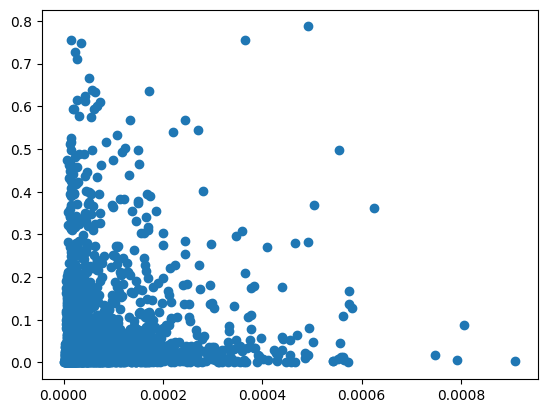

In [4]:
plt.scatter( model1._expected_residuals_squared(), model._expected_residuals_squared())

In [5]:
ER2 = model1._expected_residuals_squared()
ll = model1._compute_constant_loglik(ER2)

In [6]:
ll

tensor(6546.2197)

In [7]:
ER2 = model._expected_residuals_squared()
ll = model._compute_constant_loglik(ER2)
ll

tensor(-201.5095)

In [8]:
model.obj 

[876.7189907540138]

In [9]:
model1.obj 

[-5798.737783067031]

In [10]:
model.kl_l

tensor([18.4419, 18.3520, 13.7591, 11.2331])

In [11]:
model1.kl_l

tensor([285.7741,  36.3125,  34.7312,  32.3926,  28.2911])

In [12]:
model1.kl_l

tensor([285.7741,  36.3125,  34.7312,  32.3926,  28.2911])

In [13]:
model1.kl_f

tensor([234.5970,  27.4740,  25.9826,  22.8611,  19.0656])

In [14]:
torch.manual_seed(1)

# rank-1 signal + Gaussian noise
u = torch.rand(N, device=device)
v = torch.rand(P, device=device)
Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)


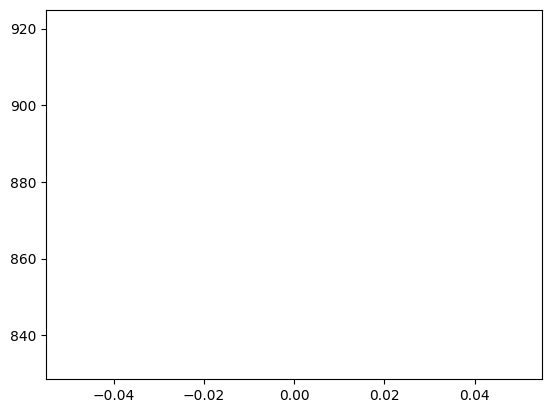

In [15]:
plt.plot(model.obj)

In [16]:

def is_strictly_increasing(xs, tol=0.0001):
    # xs[t+1] > xs[t] + tol  for all t
    return all(xs[t+1] > xs[t] - tol for t in range(len(xs)-1))

def is_strictly_decreasing(xs, tol=0.001):
    # xs[t+1] < xs[t] - tol  for all t
    return all(xs[t+1] < xs[t] + tol for t in range(len(xs)-1))

def one_run(seed):
    # reproducibility
    random.seed(seed)
    torch.manual_seed(seed)

    # rank-1 signal + Gaussian noise
    u = torch.rand(N, device=device)
    v = torch.rand(P, device=device)
    Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

    model = cEBMF(data=Y, K=5, prior_F="exp",
                 prior_L="exp", allow_backfitting=True) 
    model.fit(maxit=MAXIT)

    loss_hist = model.obj                       # your stored objective = negative ELBO
    return(loss_hist)
 


results=[]

for i in range(NUM_RUNS):
    results.append( one_run(i))
 

In [17]:
import matplotlib.pyplot as plt

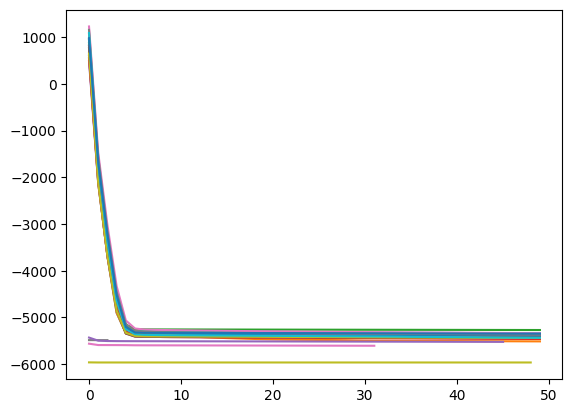

In [18]:
plt.plot(results[0])
for i in range(NUM_RUNS):
    plt.plot(results[i])

In [22]:
model.kl_l

tensor([18.4419, 18.3520, 13.7591, 11.2331])

In [23]:
h=0

for i in range(NUM_RUNS):
    if (is_strictly_decreasing(results[i], tol=0.1))== False:
        h=h+1
print(h)

0


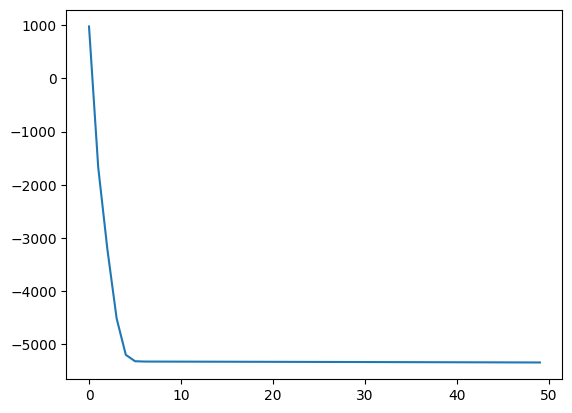

In [21]:
plt.plot(results[i])